# 01 — Exploration du dataset Sunbird

Objectif : comprendre la distribution des mesures de bruit (dB), la couverture géographique,
et vérifier que le dataset est utilisable comme base d'entraînement pour le surrogate model.

Dataset : https://huggingface.co/datasets/Sunbird/urban-noise-uganda-61k

> Prérequis : accepter les conditions d'accès sur HuggingFace et créer un token sur
> https://huggingface.co/settings/tokens

In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

# Token HF chargé depuis le fichier .env à la racine du repo (gitignoré)
from dotenv import load_dotenv
import os
load_dotenv('../.env')
HF_TOKEN = os.environ['HF_TOKEN']

ds = load_dataset("Sunbird/urban-noise-uganda-61k", "small", token=HF_TOKEN)
print(ds)

/Users/phocidae/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['audio', 'class', 'class_id', 'predicted_class', 'predicted_class_id', 'noise_measurement', 'latitude', 'longitude', 'altitude', 'accuracy', 'submitter_id', 'region', 'timestamp'],
        num_rows: 1000
    })
})


In [2]:
# Convertit en DataFrame
df = ds['train'].to_pandas()
df = df.dropna(subset=['noise_measurement', 'latitude', 'longitude'])
print(f'{len(df)} lignes chargées')
df.head()

1000 lignes chargées


,audio,class,class_id,predicted_class,predicted_class_id,noise_measurement,latitude,longitude,altitude,accuracy,submitter_id,region,timestamp
0,{'bytes': b'OggS\x00\x02\x00\x00\x00\x00\x00\x...,herbalists,10,herbalists,10,36.0,0.297385,32.574880,1176.705166,4.80,36,Kampala,2021-05-18T09:37:29.173Z
1,{'bytes': b'OggS\x00\x02\x00\x00\x00\x00\x00\x...,unclassified,19,car-or-truck,1,48.0,0.102457,32.527038,1172.800049,3.90,18,Entebbe,2023-04-19T14:50:23.736Z
2,{'bytes': b'OggS\x00\x02\x00\x00\x00\x00\x00\x...,unclassified,19,motorvehicle-horn,2,46.0,0.067772,32.474533,1159.300000,4.70,22,Entebbe,2023-04-19T07:50:43.362Z
3,{'bytes': b'OggS\x00\x02\x00\x00\x00\x00\x00\x...,unclassified,19,construction-site,11,25.0,0.086771,32.494641,1154.300000,4.95,20,Entebbe,2023-04-12T21:38:27.407Z
4,{'bytes': b'OggS\x00\x02\x00\x00\x00\x00\x00\x...,unclassified,19,animal,15,31.0,0.082354,32.515020,1166.700073,3.90,20,Entebbe,2023-04-13T17:18:09.238Z


## Distribution de noise_measurement

C'est le test clé : on a besoin d'une bonne variance (idéalement 20+ dB d'écart).

count    1000.000000
mean       47.734000
std        13.104617
min        10.000000
25%        40.000000
50%        49.000000
75%        56.000000
max        77.000000
Name: noise_measurement, dtype: float64


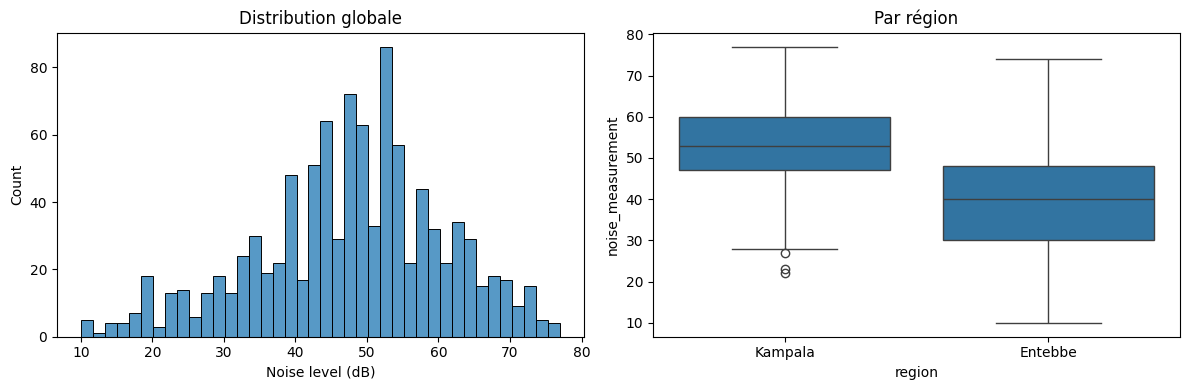

In [3]:
print(df['noise_measurement'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['noise_measurement'], bins=40, ax=axes[0])
axes[0].set_xlabel('Noise level (dB)')
axes[0].set_title('Distribution globale')

sns.boxplot(data=df, x='region', y='noise_measurement', ax=axes[1])
axes[1].set_title('Par région')

plt.tight_layout()
plt.savefig('../outputs/maps/sunbird_distribution.png', dpi=150)
plt.show()

## Carte des points de mesure

In [4]:
center_lat = df['latitude'].mean()
center_lon = df['longitude'].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

for _, row in df.sample(min(500, len(df))).iterrows():
    color = 'green' if row['noise_measurement'] < 60 else ('orange' if row['noise_measurement'] < 75 else 'red')
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        color=color,
        fill=True,
        popup=f"{row['noise_measurement']:.1f} dB — {row['class']}"
    ).add_to(m)

m.save('../outputs/maps/sunbird_map.html')
print('Carte sauvegardée dans outputs/maps/sunbird_map.html')
m

Carte sauvegardée dans outputs/maps/sunbird_map.html


## Conclusion

- **Variance suffisante ?** Si stdev > 8 dB → oui, le modèle va pouvoir apprendre
- **Distribution équilibrée ?** Vérifie qu'il n'y a pas 90% des points dans une seule tranche
- **Couverture géographique ?** Zones résidentielles, commerciales, routes principales bien représentées ?